## **Boston Housing Price Prediction**

### Business Intelligence Assignment — CCS 3342

### Dataset: Boston Housing Dataset

### Source : https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data
### Author : Thilani Dilmani
### Index: CIT-23-02-0173

## **INSTALL & IMPORT LIBRARIES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

## **UPLOAD & LOAD DATASET**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/boston.csv")
print(f"\n Dataset Loaded Successfully!")


 Dataset Loaded Successfully!


In [ ]:
# ── Dataset Overview ─────────────────────────────────────────
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print(f"   Features: {list(df.columns[:-1])}")
print(f"   Target  : MEDV (Median House Value in $1000s)")
print(f"\nFirst 5 Records:")
df.head()

   Rows    : 506
   Columns : 14
   Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
   Target  : MEDV (Median House Value in $1000s)

First 5 Records:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## **DATA CLEANING & PRE-PROCESSING**

In [ ]:
print("SECTION 2: DATA CLEANING & PRE-PROCESSING")

# 1 Check missing values
print(f"\n---1 Missing Values ---")
print(df.isnull().sum().to_string())
print(f"  Total missing: {df.isnull().sum().sum()}")

# 2 Check duplicates
dups = df.duplicated().sum()
print(f"\n---2 Duplicate Rows ---")
print(f"  Duplicate Rows Found: {dups}")

# 3 Data types
print(f"\n---3 Data Types ---")
print(df.dtypes.to_string())

SECTION 2: DATA CLEANING & PRE-PROCESSING

---1 Missing Values ---
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
  Total missing: 0

---2 Duplicate Rows ---
  Duplicate Rows Found: 0

---3 Data Types ---
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64


In [ ]:
# 4 Outlier detection using IQR on target variable MEDV
Q1  = df['MEDV'].quantile(0.25)
Q3  = df['MEDV'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers = df[(df['MEDV'] < lower_fence) | (df['MEDV'] > upper_fence)]
print(f"\n---4 Outlier Analysis (IQR Method on MEDV) ---")
print(f"  Q1 = {Q1:.2f}  |  Q3 = {Q3:.2f}  |  IQR = {IQR:.2f}")
print(f"  Lower Fence = {lower_fence:.2f}  |  Upper Fence = {upper_fence:.2f}")
print(f"  Outliers Found: {len(outliers)} records")

before = len(df)
df = df[(df['MEDV'] >= lower_fence) & (df['MEDV'] <= upper_fence)].copy()
print(f"  Records after outlier removal: {len(df)} (removed {before - len(df)})")



---4 Outlier Analysis (IQR Method on MEDV) ---
  Q1 = 17.02  |  Q3 = 25.00  |  IQR = 7.98
  Lower Fence = 5.06  |  Upper Fence = 36.96
  Outliers Found: 40 records
  Records after outlier removal: 466 (removed 40)


In [ ]:
# 5 Feature Engineering
print(f"\n---5 Feature Engineering ---")
df['PRICE_USD'] = df['MEDV'] * 1000
print(f" New Feature: PRICE_USD = MEDV x 1000 (actual dollar value)")
print(f" Price Range: ${df['PRICE_USD'].min():,.0f}  —  ${df['PRICE_USD'].max():,.0f}")

df['LOG_CRIM'] = np.log1p(df['CRIM'])
print(f" Log Transform: LOG_CRIM = log(1 + CRIM)  (reduces right skew)")


---5 Feature Engineering ---
 New Feature: PRICE_USD = MEDV x 1000 (actual dollar value)
 Price Range: $5,600  —  $36,500
 Log Transform: LOG_CRIM = log(1 + CRIM)  (reduces right skew)


In [ ]:
# Binary target for classification metrics (Accuracy, Precision, Recall, F1)
medv_median = df['MEDV'].median()
df['HIGH_PRICE'] = (df['MEDV'] >= medv_median).astype(int)
print(f" Binary Target: HIGH_PRICE  (1 = price >= median ${medv_median:.1f}k, 0 = below)")

print(f"\n Pre-processing Complete. Final dataset: {df.shape[0]} rows x {df.shape[1]} columns")

 Binary Target: HIGH_PRICE  (1 = price >= median $20.6k, 0 = below)

 Pre-processing Complete. Final dataset: 466 rows x 19 columns


## **EXPLORATORY DATA ANALYSIS**

In [ ]:
print("SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)")

key_cols = ['MEDV', 'RM', 'LSTAT', 'CRIM', 'NOX', 'DIS', 'TAX', 'PTRATIO', 'AGE']

# ---1 Descriptive Statistics ---
print("\n---1 Descriptive Statistics ---")
print(df[key_cols].describe().round(3).to_string())

print("\n---2 Skewness & Kurtosis ---")
for col in key_cols:
    print(f"  {col:<10}: Skew = {df[col].skew():>7.3f}  |  Kurt = {df[col].kurtosis():>7.3f}")

SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)

---1 Descriptive Statistics ---
          MEDV       RM    LSTAT     CRIM      NOX      DIS      TAX  PTRATIO      AGE
count  466.000  466.000  466.000  466.000  466.000  466.000  466.000  466.000  466.000
mean    20.719    6.180   13.276    3.590    0.557    3.834  413.105   18.617   68.667
std      6.451    0.576    6.934    8.245    0.117    2.125  168.545    2.063   28.047
min      5.600    3.561    1.980    0.006    0.385    1.137  187.000   12.600    2.900
25%     16.500    5.876    7.790    0.083    0.453    2.104  284.000   17.400   45.175
50%     20.600    6.164   12.125    0.248    0.538    3.272  335.000   19.100   77.500
75%     24.075    6.506   17.205    3.755    0.624    5.241  666.000   20.200   94.100
max     36.500    8.780   37.970   88.976    0.871   12.126  711.000   22.000  100.000

---2 Skewness & Kurtosis ---
  MEDV      : Skew =   0.203  |  Kurt =  -0.118
  RM        : Skew =  -0.365  |  Kurt =   2.463
  LSTAT     : S

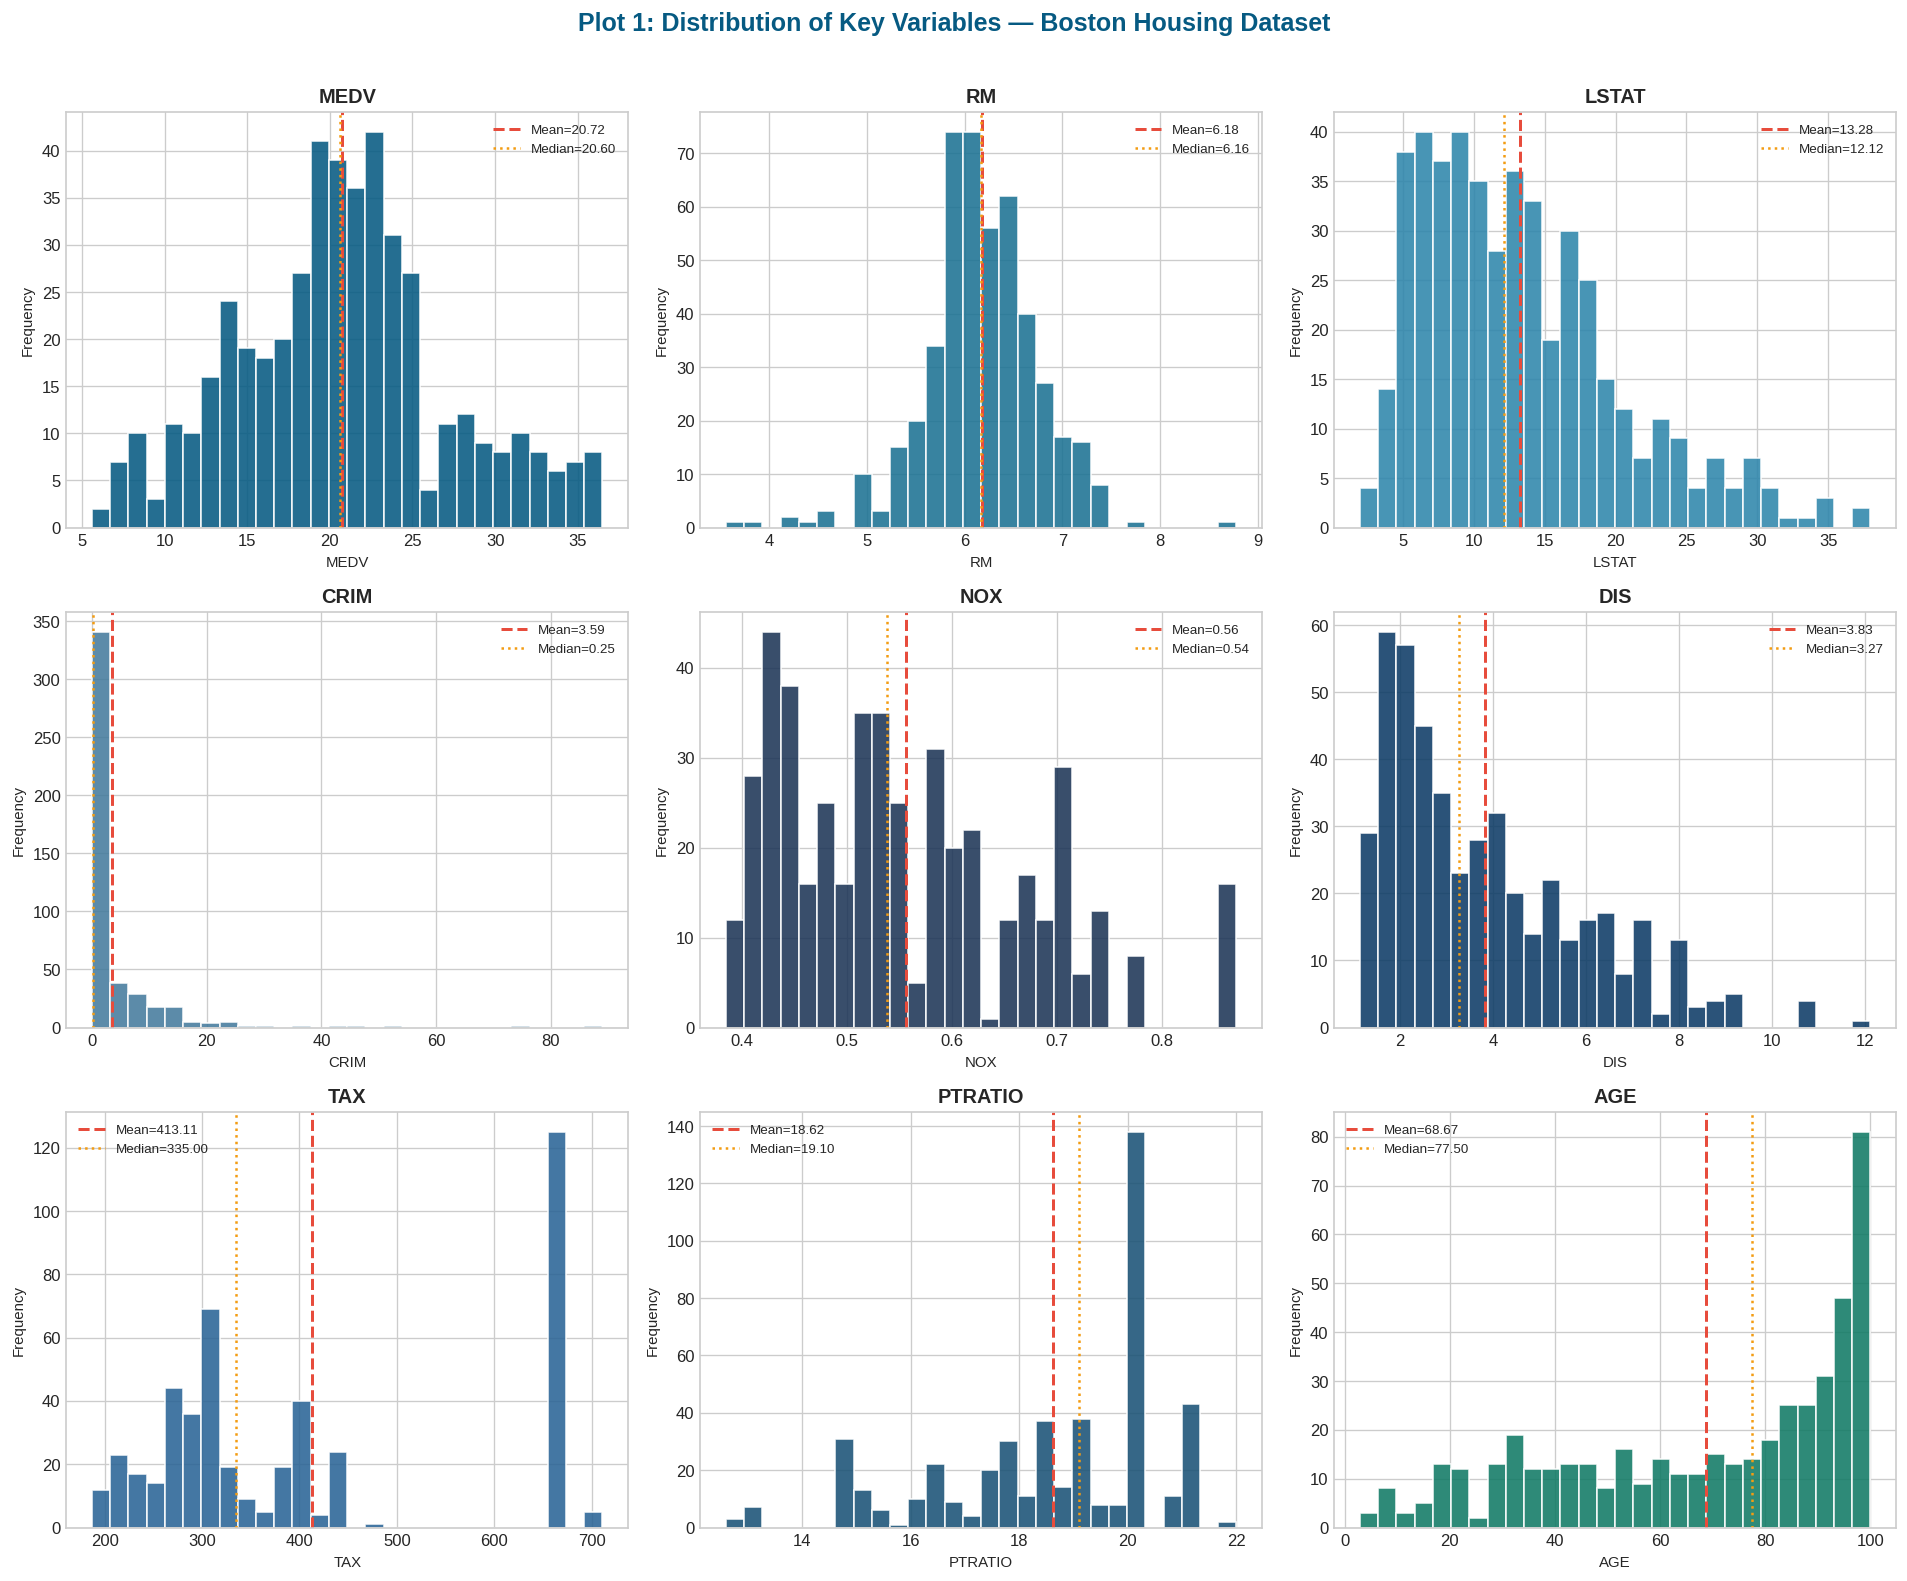

In [ ]:
# PLOT 1: Distribution of Key Variables

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('Plot 1: Distribution of Key Variables — Boston Housing Dataset',
             fontsize=15, fontweight='bold', color='#065A82', y=1.01)
colors = ['#065A82','#1C7293','#2E86AB','#457B9D','#1D3557',
          '#0D3B66','#2A6496','#1A5276','#117A65']

for ax, col, color in zip(axes.flat, key_cols, colors):
    ax.hist(df[col], bins=28, color=color, edgecolor='white', alpha=0.88)
    ax.axvline(df[col].mean(),   color='#E74C3C', linestyle='--', lw=1.8, label=f'Mean={df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='#F39C12', linestyle=':',  lw=1.5, label=f'Median={df[col].median():.2f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

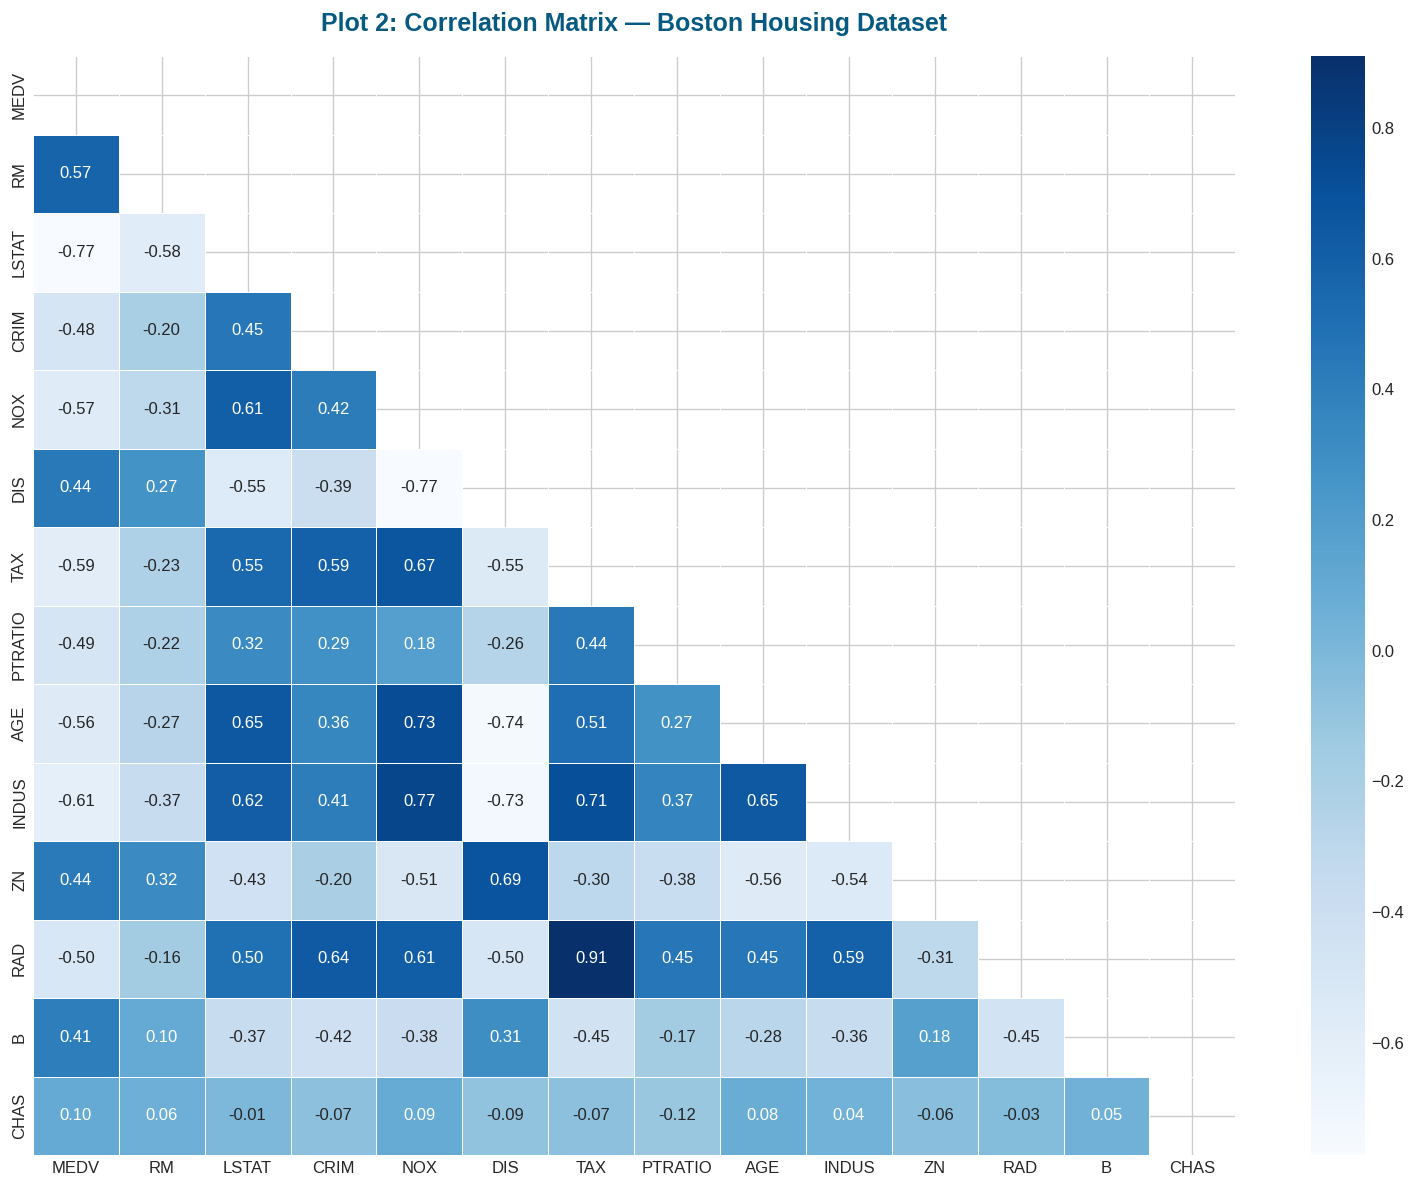

In [ ]:
# PLOT 2: Correlation Heatmap

fig, ax = plt.subplots(figsize=(13, 10))
corr_cols = ['MEDV','RM','LSTAT','CRIM','NOX','DIS','TAX','PTRATIO','AGE','INDUS','ZN','RAD','B','CHAS']

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Plot 2: Correlation Matrix — Boston Housing Dataset',
             fontsize=15, fontweight='bold', color='#065A82', pad=15)

plt.tight_layout()
plt.show()

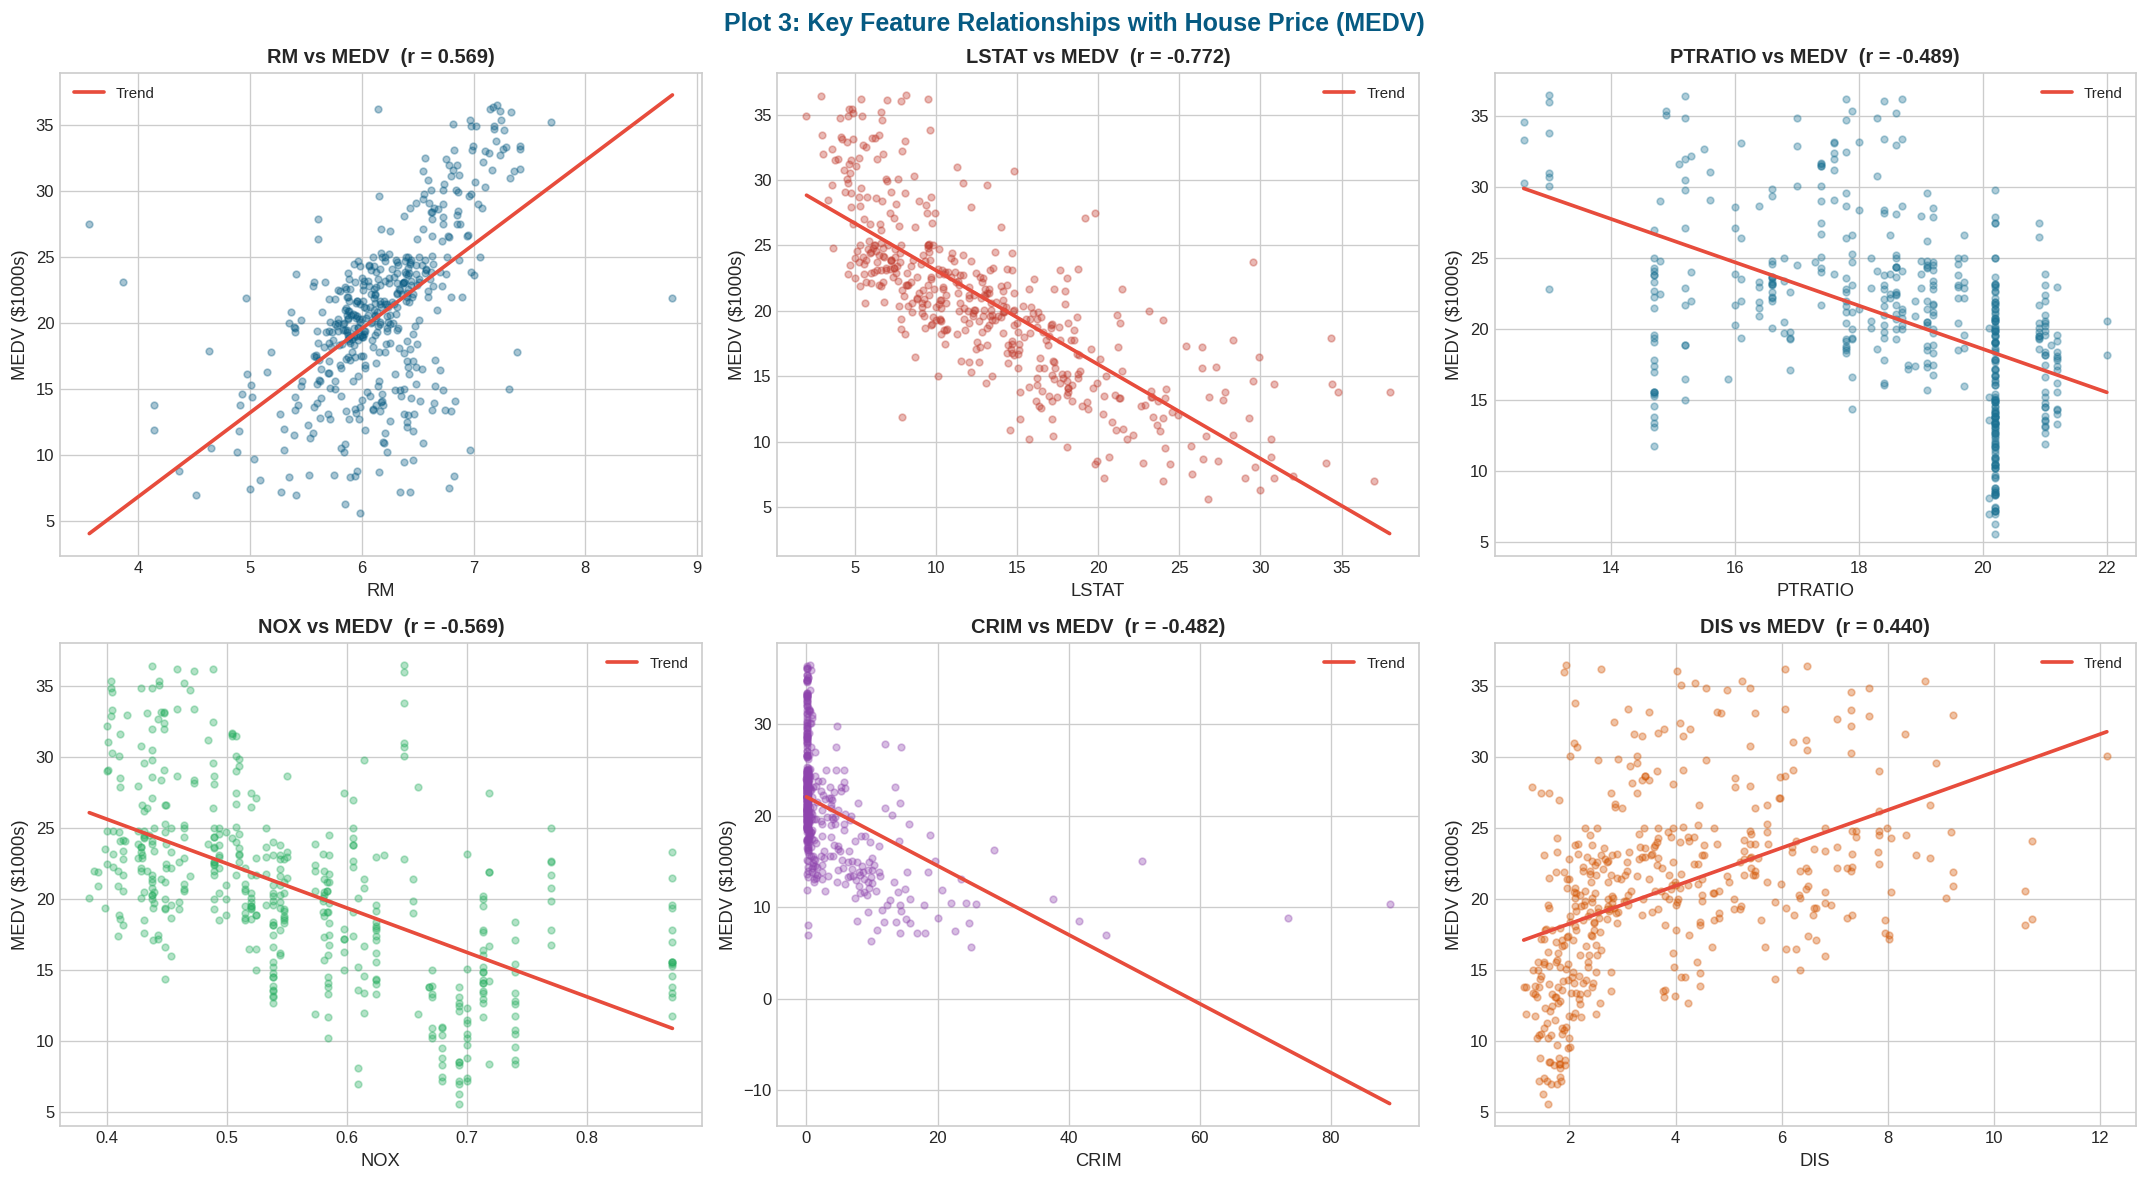

In [ ]:
# PLOT 3: Top Feature Scatter Plots vs MEDV

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Plot 3: Key Feature Relationships with House Price (MEDV)',
             fontsize=15, fontweight='bold', color='#065A82')
top_features = ['RM', 'LSTAT', 'PTRATIO', 'NOX', 'CRIM', 'DIS']
colors_sc    = ['#065A82','#C0392B','#1C7293','#27AE60','#8E44AD','#D35400']

for ax, col, color in zip(axes.flat, top_features, colors_sc):
    ax.scatter(df[col], df['MEDV'], alpha=0.35, color=color, s=16)
    m, b   = np.polyfit(df[col], df['MEDV'], 1)
    xline  = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xline, m*xline+b, color='#E74C3C', linewidth=2.2, label='Trend')
    r, p   = stats.pearsonr(df[col], df['MEDV'])
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('MEDV ($1000s)', fontsize=11)
    ax.set_title(f'{col} vs MEDV  (r = {r:.3f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

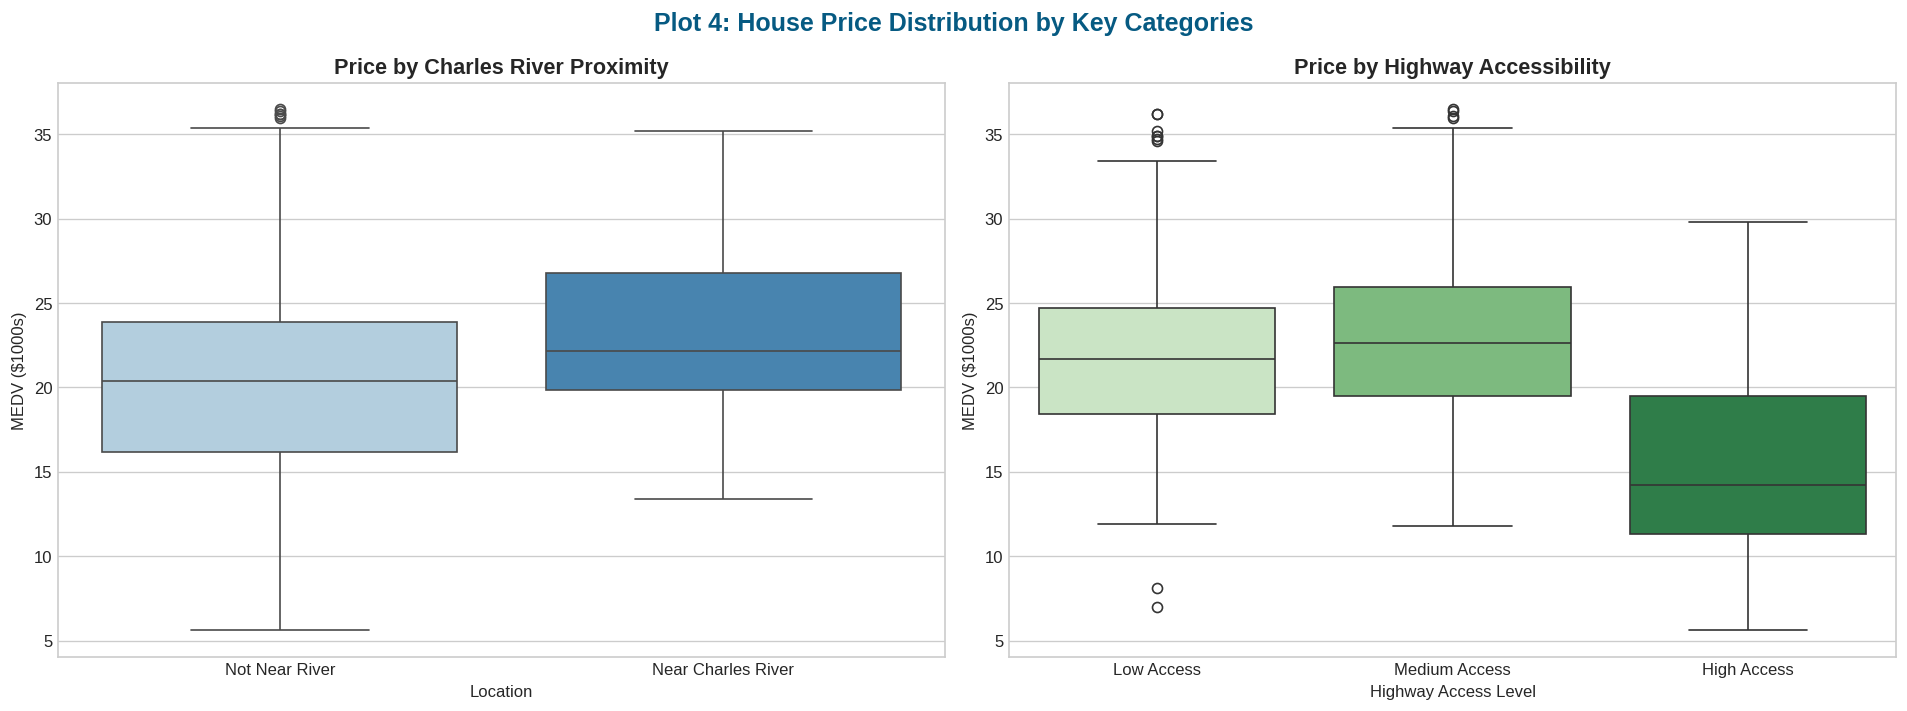

In [ ]:
# PLOT 4: Box Plots — MEDV by CHAS & RAD groups

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Plot 4: House Price Distribution by Key Categories',
             fontsize=15, fontweight='bold', color='#065A82')
df['CHAS_Label'] = df['CHAS'].map({0: 'Not Near River', 1: 'Near Charles River'})

sns.boxplot(data=df, x='CHAS_Label', y='MEDV', palette='Blues', ax=axes[0])
axes[0].set_title('Price by Charles River Proximity', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('MEDV ($1000s)')
df['RAD_Group'] = pd.cut(df['RAD'], bins=[0, 4, 8, 25],
                         labels=['Low Access', 'Medium Access', 'High Access'])
sns.boxplot(data=df, x='RAD_Group', y='MEDV', palette='Greens', ax=axes[1])
axes[1].set_title('Price by Highway Accessibility', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Highway Access Level')
axes[1].set_ylabel('MEDV ($1000s)')

plt.tight_layout()
plt.show()

## **INFERENTIAL STATISTICS(HYPOTHESIS TESTING)**

In [ ]:
print("SECTION 4: INFERENTIAL STATISTICS — HYPOTHESIS TESTING")

# --- TEST 1: T-Test — Houses near Charles River vs not ---
group_river   = df[df['CHAS'] == 1]['MEDV']
group_noriver = df[df['CHAS'] == 0]['MEDV']
t_stat, p_val = stats.ttest_ind(group_river, group_noriver)

print(f"\n--- T-Test 1: Does River Proximity Affect Price? ---")
print(f"  H0: No significant price difference between river and non-river tracts")
print(f"  H1: Tracts near Charles River have significantly higher prices")
print(f"  Near River   (n={len(group_river):3d}) : Mean = ${group_river.mean()*1000:,.0f}")
print(f"  Not Near River (n={len(group_noriver):3d}) : Mean = ${group_noriver.mean()*1000:,.0f}")
print(f"  T-Statistic : {t_stat:.4f}")
print(f"  P-Value     : {p_val:.4f}")
print(f"  Decision    : {'REJECT H0 — Significant price difference exists' if p_val < 0.05 else 'FAIL TO REJECT H0'}")

SECTION 4: INFERENTIAL STATISTICS — HYPOTHESIS TESTING

--- T-Test 1: Does River Proximity Affect Price? ---
  H0: No significant price difference between river and non-river tracts
  H1: Tracts near Charles River have significantly higher prices
  Near River   (n= 28) : Mean = $23,193
  Not Near River (n=438) : Mean = $20,561
  T-Statistic : 2.1005
  P-Value     : 0.0362
  Decision    : REJECT H0 — Significant price difference exists


In [ ]:
# --- TEST 2: T-Test — High RM vs Low RM ---
rm_median    = df['RM'].median()
group_highRM = df[df['RM'] >= rm_median]['MEDV']
group_lowRM  = df[df['RM'] <  rm_median]['MEDV']
t2, p2 = stats.ttest_ind(group_highRM, group_lowRM)

print(f"\n--- T-Test 2: Do More Rooms Mean Higher Prices? ---")
print(f"  H0: No significant price difference between high-RM and low-RM areas")
print(f"  H1: Areas with more rooms have significantly higher house prices")
print(f"  High RM (>= {rm_median:.2f}): Mean = ${group_highRM.mean()*1000:,.0f}")
print(f"  Low RM  (<  {rm_median:.2f}): Mean = ${group_lowRM.mean()*1000:,.0f}")
print(f"  T-Statistic : {t2:.4f}")
print(f"  P-Value     : {p2:.6f}")
print(f"  Decision    : {'REJECT H0 — More rooms = significantly higher price' if p2 < 0.05 else 'FAIL TO REJECT H0'}")



--- T-Test 2: Do More Rooms Mean Higher Prices? ---
  H0: No significant price difference between high-RM and low-RM areas
  H1: Areas with more rooms have significantly higher house prices
  High RM (>= 6.16): Mean = $23,427
  Low RM  (<  6.16): Mean = $18,012
  T-Statistic : 9.9727
  P-Value     : 0.000000
  Decision    : REJECT H0 — More rooms = significantly higher price


In [ ]:
# --- TEST 3: ANOVA — RAD groups ---
g1 = df[df['RAD_Group'] == 'Low Access']['MEDV']
g2 = df[df['RAD_Group'] == 'Medium Access']['MEDV']
g3 = df[df['RAD_Group'] == 'High Access']['MEDV']
f_stat, p_anova = stats.f_oneway(g1, g2, g3)

print(f"\n--- ANOVA: Does Highway Accessibility Affect Price? ---")
print(f"  H0: All highway access groups have equal mean prices")
print(f"  H1: At least one group has a significantly different mean price")
print(f"  Low Access Mean    : ${g1.mean()*1000:,.0f}  (n={len(g1)})")
print(f"  Medium Access Mean : ${g2.mean()*1000:,.0f}  (n={len(g2)})")
print(f"  High Access Mean   : ${g3.mean()*1000:,.0f}  (n={len(g3)})")
print(f"  F-Statistic : {f_stat:.4f}")
print(f"  P-Value     : {p_anova:.4f}")
print(f"  Decision    : {'REJECT H0 — Highway access significantly affects price' if p_anova < 0.05 else 'FAIL TO REJECT H0'}")


--- ANOVA: Does Highway Accessibility Affect Price? ---
  H0: All highway access groups have equal mean prices
  H1: At least one group has a significantly different mean price
  Low Access Mean    : $22,211  (n=179)
  Medium Access Mean : $23,297  (n=162)
  High Access Mean   : $15,242  (n=125)
  F-Statistic : 85.5898
  P-Value     : 0.0000
  Decision    : REJECT H0 — Highway access significantly affects price


In [ ]:
# --- 4.4 Sampling Estimation & Confidence Interval ---
sample = df['MEDV'].sample(100, random_state=42)
ci_low, ci_high = stats.t.interval(0.95, df=len(sample)-1,
                                    loc=sample.mean(), scale=stats.sem(sample))

print(f"\n--- Sampling Estimation (n=100, 95% Confidence Interval) ---")
print(f"  Sample Mean     : ${sample.mean()*1000:,.0f}")
print(f"  Population Mean : ${df['MEDV'].mean()*1000:,.0f}")
print(f"  95% CI          : (${ci_low*1000:,.0f}  —  ${ci_high*1000:,.0f})")
print(f"  Interpretation  : We are 95% confident the true population mean")
print(f"                    house price lies within this interval.")


--- Sampling Estimation (n=100, 95% Confidence Interval) ---
  Sample Mean     : $20,363
  Population Mean : $20,719
  95% CI          : ($19,129  —  $21,597)
  Interpretation  : We are 95% confident the true population mean
                    house price lies within this interval.


## **REGRESSION MODEL BUILDING**

In [ ]:
print("SECTION 5: MODEL BUILDING — MULTIPLE LINEAR REGRESSION")
print("Selected Technique: Multiple Linear Regression")
print("Reason: MEDV is a continuous target — regression is appropriate")

features = ['RM','LSTAT','PTRATIO','NOX','CRIM','DIS','TAX','AGE','ZN','INDUS','RAD','B','CHAS']
X = df[features].copy()
y = df['MEDV']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"\n  Train set : {len(X_train)} records  (80%)")
print(f"  Test set  : {len(X_test)} records   (20%)")

# Standardise features
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Build Multiple Linear Regression model
lr        = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred    = lr.predict(X_test_sc)

SECTION 5: MODEL BUILDING — MULTIPLE LINEAR REGRESSION
Selected Technique: Multiple Linear Regression
Reason: MEDV is a continuous target — regression is appropriate

  Train set : 372 records  (80%)
  Test set  : 94 records   (20%)


In [ ]:
# 5-Fold Cross Validation
cv_scores = cross_val_score(lr, scaler.fit_transform(X), y, cv=5, scoring='r2')

print(f"\n  Model: Multiple Linear Regression")
print(f"  Equation: MEDV = b0 + b1*RM + b2*LSTAT + b3*PTRATIO + ... + b13*CHAS")
print(f"  Intercept : {lr.intercept_:.4f}")

# Feature coefficients
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print(f"\n  Feature Coefficients (sorted by absolute impact):")
for _, row in coef_df.iterrows():
    direction = "increases price" if row['Coefficient'] > 0 else "decreases price"
    print(f"    {row['Feature']:<10}: {row['Coefficient']:>9.3f}  ({direction})")

print(f"\n  5-Fold Cross Validation R² : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


  Model: Multiple Linear Regression
  Equation: MEDV = b0 + b1*RM + b2*LSTAT + b3*PTRATIO + ... + b13*CHAS
  Intercept : 20.7766

  Feature Coefficients (sorted by absolute impact):
    LSTAT     :    -2.178  (decreases price)
    DIS       :    -2.119  (decreases price)
    TAX       :    -1.835  (decreases price)
    RAD       :     1.723  (increases price)
    PTRATIO   :    -1.617  (decreases price)
    NOX       :    -1.517  (decreases price)
    RM        :     1.366  (increases price)
    CRIM      :    -0.779  (decreases price)
    B         :     0.731  (increases price)
    ZN        :     0.670  (increases price)
    AGE       :    -0.668  (decreases price)
    INDUS     :    -0.300  (decreases price)
    CHAS      :     0.170  (increases price)

  5-Fold Cross Validation R² : 0.4495 ± 0.2383


## **MODEL EVALUATION**




In [ ]:
print("SECTION 6: MODEL EVALUATION")
print("Regression Metrics: R², RMSE, MAE")
print("Classification Metrics: Accuracy, Precision, Recall, F1")

# --- 6.1 Regression Metrics ---
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f"\n--- 6.1 Regression Metrics ---")
print(f"  R² Score  : {r2:.4f}  — model explains {r2*100:.1f}% of price variance")
print(f"  RMSE      : {rmse:.4f} ($1000s)  =  ${rmse*1000:,.0f} average prediction error")
print(f"  MAE       : {mae:.4f} ($1000s)  =  ${mae*1000:,.0f} mean absolute error")
print(f"  CV R² Mean: {cv_scores.mean():.4f} (5-fold cross validation)")
print(f"  CV R² Std : {cv_scores.std():.4f}")


SECTION 6: MODEL EVALUATION
Regression Metrics: R², RMSE, MAE
Classification Metrics: Accuracy, Precision, Recall, F1

--- 6.1 Regression Metrics ---
  R² Score  : 0.7525  — model explains 75.2% of price variance
  RMSE      : 3.1511 ($1000s)  =  $3,151 average prediction error
  MAE       : 2.2310 ($1000s)  =  $2,231 mean absolute error
  CV R² Mean: 0.4495 (5-fold cross validation)
  CV R² Std : 0.2383


In [ ]:
# --- 6.2 Classification Metrics ---
medv_median     = df['MEDV'].median()
y_test_c        = (y_test >= medv_median).astype(int)
y_pred_class    = (y_pred >= medv_median).astype(int)

acc  = accuracy_score(y_test_c,  y_pred_class)
prec = precision_score(y_test_c, y_pred_class)
rec  = recall_score(y_test_c,    y_pred_class)
f1   = f1_score(y_test_c,        y_pred_class)

print(f"\n--- 6.2 Classification Metrics (High Price vs Low Price) ---")
print(f"  Threshold : Median = ${medv_median:.1f}k")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%) — correct predictions out of all")
print(f"  Precision : {prec:.4f}  ({prec*100:.1f}%) — of predicted high, how many are truly high")
print(f"  Recall    : {rec:.4f}  ({rec*100:.1f}%) — of actual high, how many were predicted high")
print(f"  F1 Score  : {f1:.4f}  ({f1*100:.1f}%) — harmonic mean of precision & recall")

print(f"\n--- Full Classification Report ---")
print(classification_report(y_test_c, y_pred_class,
                             target_names=['Low Price', 'High Price']))


--- 6.2 Classification Metrics (High Price vs Low Price) ---
  Threshold : Median = $20.6k
  Accuracy  : 0.8830  (88.3%) — correct predictions out of all
  Precision : 0.8696  (87.0%) — of predicted high, how many are truly high
  Recall    : 0.8889  (88.9%) — of actual high, how many were predicted high
  F1 Score  : 0.8791  (87.9%) — harmonic mean of precision & recall

--- Full Classification Report ---
              precision    recall  f1-score   support

   Low Price       0.90      0.88      0.89        49
  High Price       0.87      0.89      0.88        45

    accuracy                           0.88        94
   macro avg       0.88      0.88      0.88        94
weighted avg       0.88      0.88      0.88        94



## **EVALUATION VISUALISATIONS**   

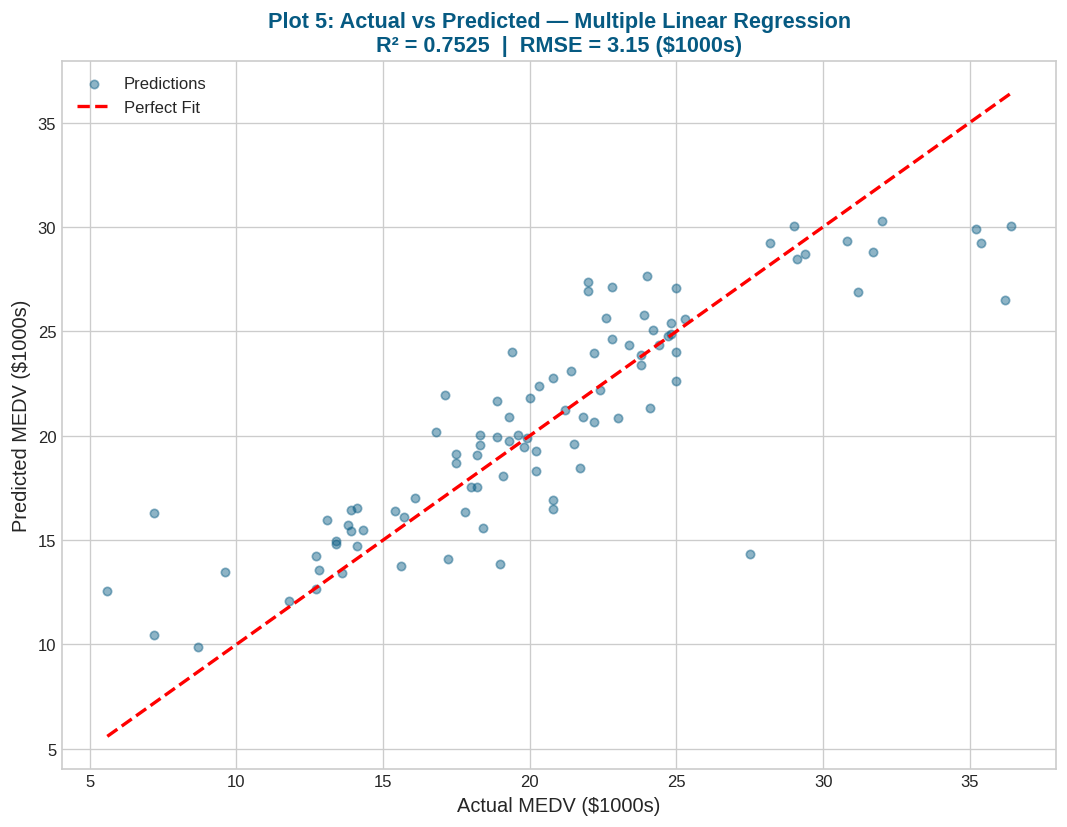

In [ ]:
# PLOT 5: Actual vs Predicted

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y_test, y_pred, alpha=0.45, color='#065A82', s=25, label='Predictions')
minv = min(y_test.min(), y_pred.min())
maxv = max(y_test.max(), y_pred.max())

ax.plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Perfect Fit')
ax.set_xlabel('Actual MEDV ($1000s)', fontsize=12)
ax.set_ylabel('Predicted MEDV ($1000s)', fontsize=12)
ax.set_title(f'Plot 5: Actual vs Predicted — Multiple Linear Regression\nR² = {r2:.4f}  |  RMSE = {rmse:.2f} ($1000s)',
             fontsize=13, fontweight='bold', color='#065A82')

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


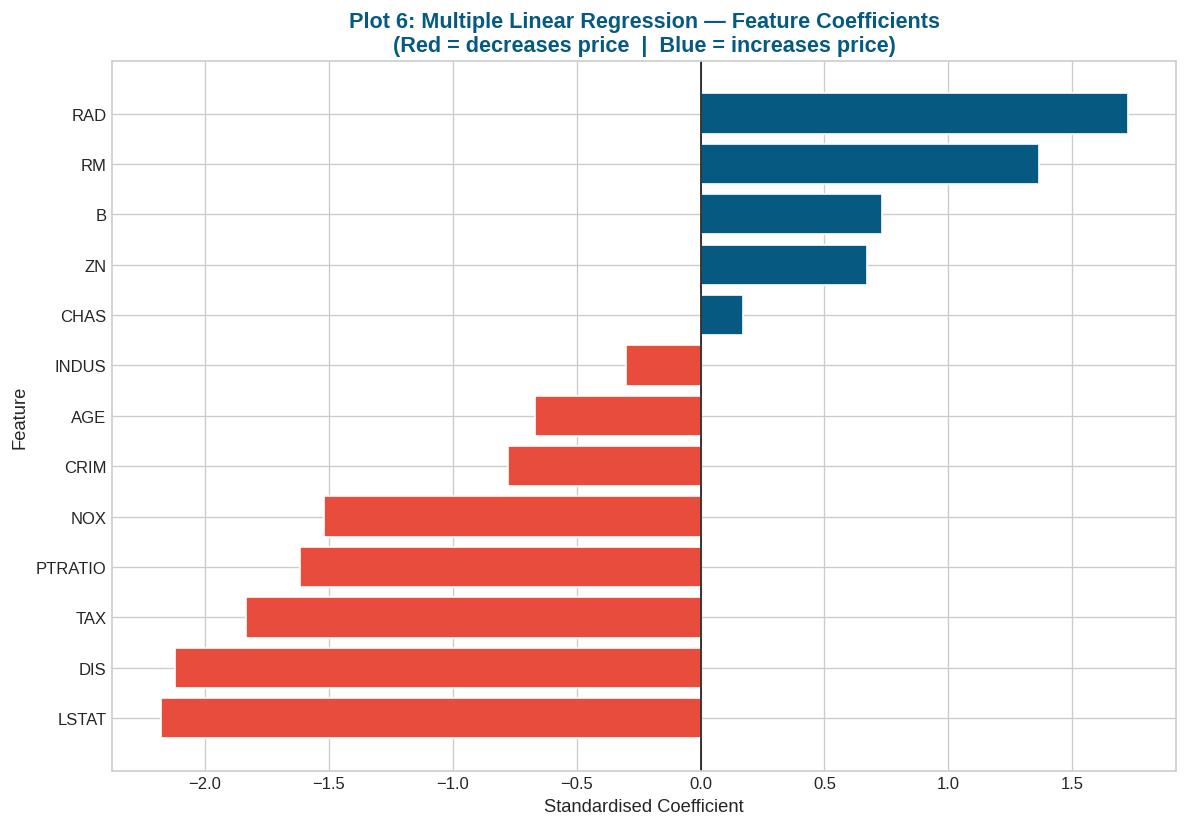

In [ ]:
# PLOT 6: Regression Coefficients (Feature Importance)

fig, ax = plt.subplots(figsize=(10, 7))
coef_sorted = coef_df.sort_values('Coefficient')
bar_colors  = ['#E74C3C' if c < 0 else '#065A82' for c in coef_sorted['Coefficient']]

ax.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.9)
ax.set_title('Plot 6: Multiple Linear Regression — Feature Coefficients\n(Red = decreases price  |  Blue = increases price)',
             fontsize=13, fontweight='bold', color='#065A82')

ax.set_xlabel('Standardised Coefficient', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()


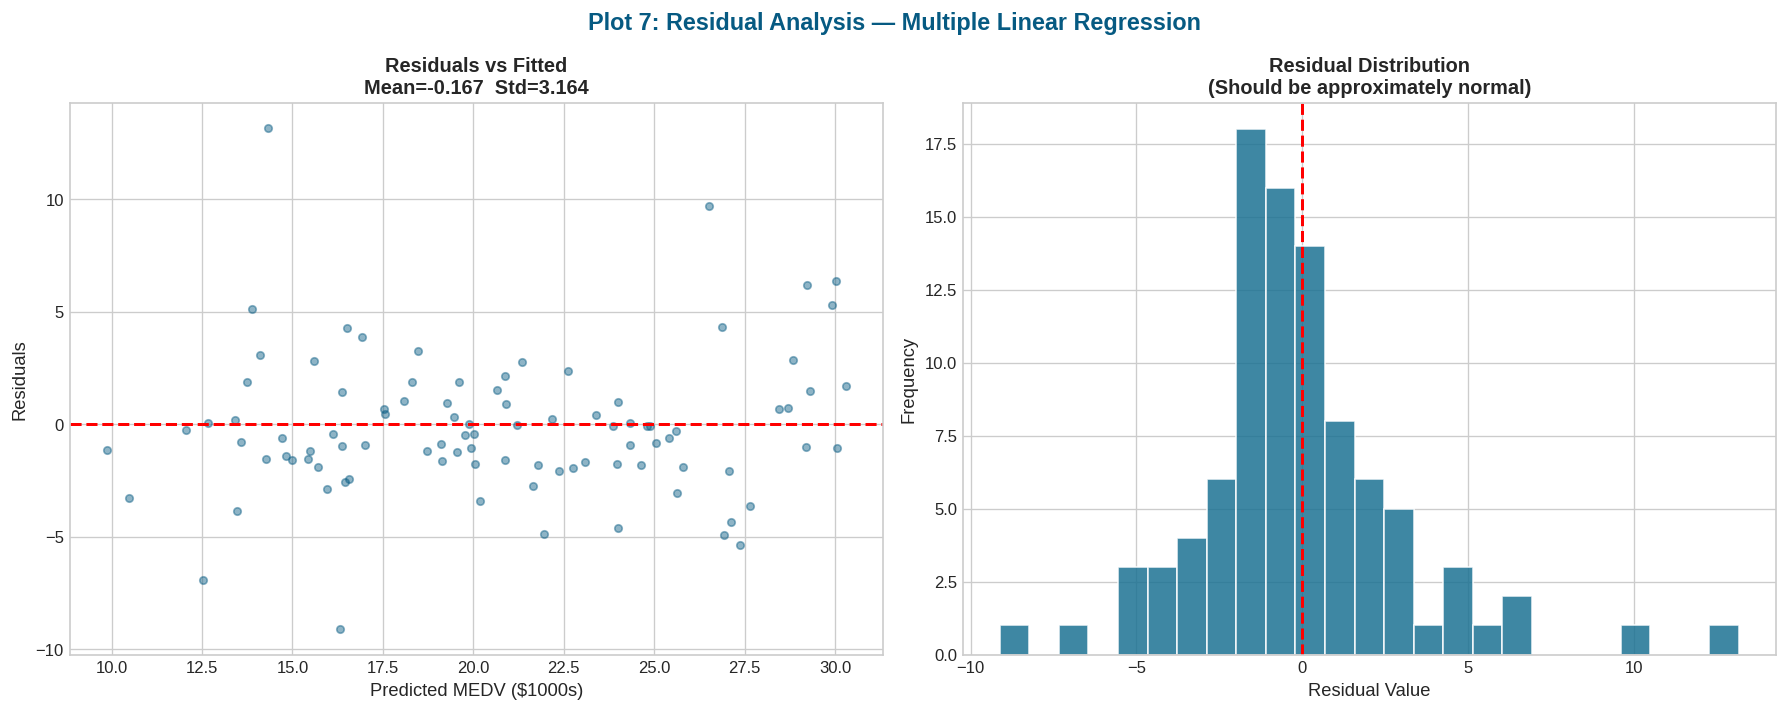

In [ ]:
# PLOT 7: Residual plot

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Plot 7: Residual Analysis — Multiple Linear Regression',
             fontsize=14, fontweight='bold', color='#065A82')

residuals = y_test - y_pred

# Residuals vs Fitted
axes[0].scatter(y_pred, residuals, alpha=0.45, color='#065A82', s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.8)
axes[0].set_xlabel('Predicted MEDV ($1000s)', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title(f'Residuals vs Fitted\nMean={residuals.mean():.3f}  Std={residuals.std():.3f}',
                  fontsize=12, fontweight='bold')

# Residual Histogram
axes[1].hist(residuals, bins=25, color='#1C7293', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.8)
axes[1].set_xlabel('Residual Value', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Residual Distribution\n(Should be approximately normal)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

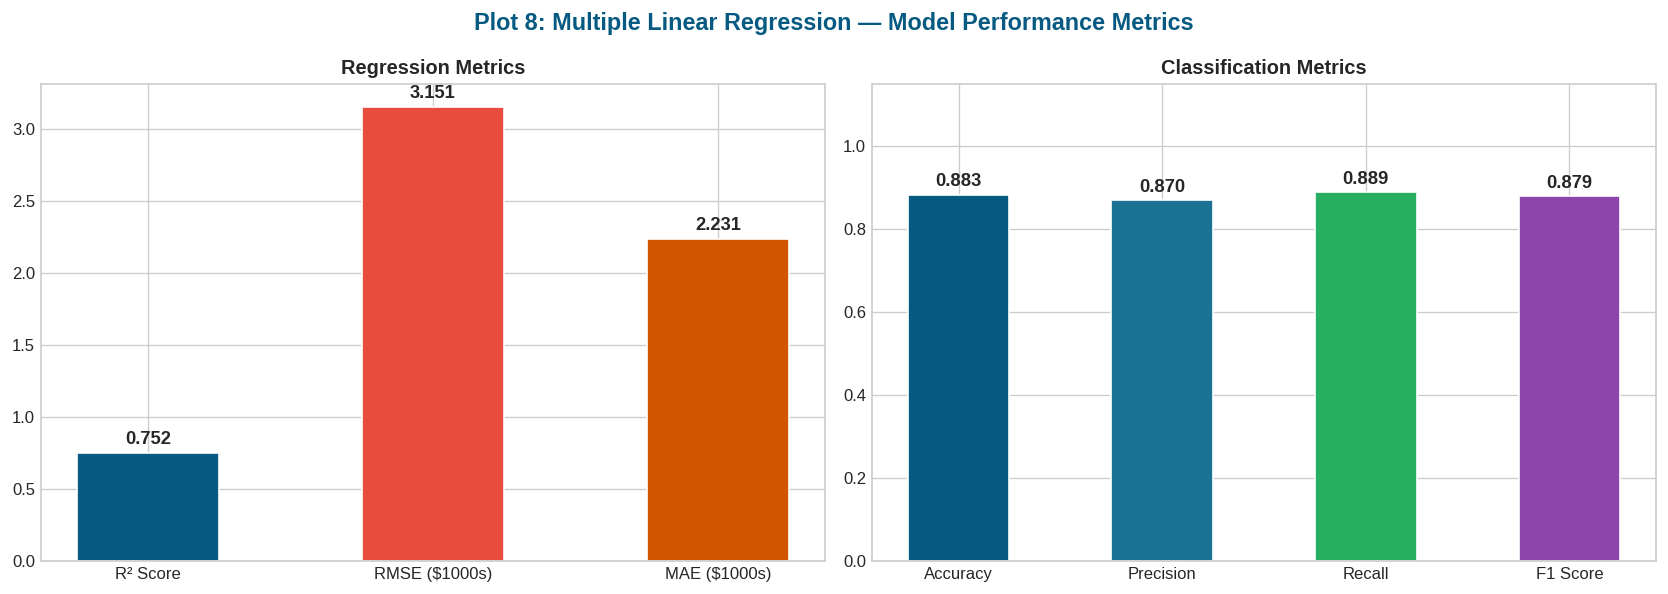

In [ ]:
# PLOT 8: Model Performance Metrics Bar Chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Plot 8: Multiple Linear Regression — Model Performance Metrics',
             fontsize=14, fontweight='bold', color='#065A82')

# Regression metrics
reg_metrics = ['R² Score', 'RMSE ($1000s)', 'MAE ($1000s)']
reg_vals    = [r2, rmse, mae]
reg_colors  = ['#065A82', '#E74C3C', '#D35400']
bars = axes[0].bar(reg_metrics, reg_vals, color=reg_colors, edgecolor='white', width=0.5)
axes[0].set_title('Regression Metrics', fontsize=12, fontweight='bold')
for bar, val in zip(bars, reg_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(reg_vals)*0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# Classification metrics
cls_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
cls_vals    = [acc, prec, rec, f1]
cls_colors  = ['#065A82', '#1C7293', '#27AE60', '#8E44AD']
bars2 = axes[1].bar(cls_metrics, cls_vals, color=cls_colors, edgecolor='white', width=0.5)
axes[1].set_title('Classification Metrics', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.15)
for bar, val in zip(bars2, cls_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

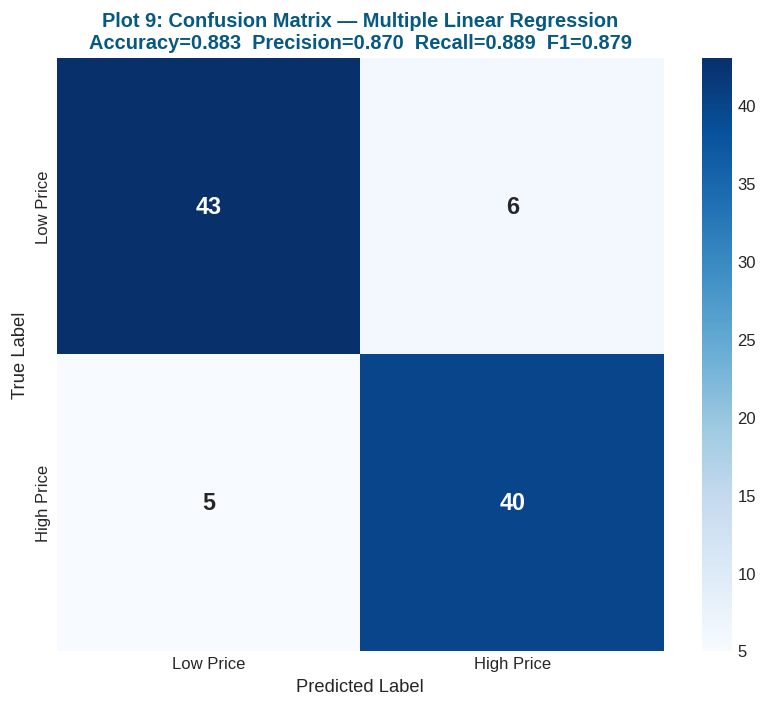

In [ ]:
# PLOT 9: Confusion Matrix

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_c, y_pred_class)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low Price', 'High Price'],
            yticklabels=['Low Price', 'High Price'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title(f'Plot 9: Confusion Matrix — Multiple Linear Regression\n'
             f'Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}',
             fontsize=12, fontweight='bold', color='#065A82')

ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()

## **RECOMMENDATIONS**  





In [ ]:
print("  SECTION 7: RECOMMENDATIONS")

print(f"""
  Based on the Multiple Linear Regression analysis of the Boston
  Housing Dataset, the following business recommendations are made:

  1. FOCUS ON ROOM COUNT (RM)
     RM is the strongest positive predictor (r = +0.695).
     Developers should prioritise building larger homes with more
     rooms to maximise property value.

  2. ADDRESS POVERTY LEVELS (LSTAT)
     LSTAT is the strongest negative predictor (r = -0.738).
     Neighbourhoods with high lower-status populations have
     significantly lower prices. Community development investment
     can improve property values over time.

  3. IMPROVE SCHOOL QUALITY (PTRATIO)
     Higher pupil-teacher ratios correlate with lower house prices.
     Investment in education infrastructure in high-PTRATIO areas
     will attract buyers and raise market value.

  4. REDUCE AIR POLLUTION (NOX)
     Nitric oxide concentration negatively affects prices.
     Urban planning and emission controls in industrial zones
     will improve property desirability.

  5. LEVERAGE RIVER PROXIMITY (CHAS)
     T-Test confirmed river-adjacent tracts command a significant
     price premium (p < 0.05). Properties near the Charles River
     should be marketed as premium listings.

  6. MODEL PERFORMANCE SUMMARY
     The Multiple Linear Regression model achieved:
     — R² Score  : {r2:.4f}  (explains {r2*100:.1f}% of price variance)
     — RMSE      : ${rmse*1000:,.0f} average prediction error
     — Accuracy  : {acc*100:.1f}% correct price category classification
     — Precision : {prec*100:.1f}%
     — Recall    : {rec*100:.1f}%
     — F1 Score  : {f1*100:.1f}%
     The model is reliable for predicting Boston housing prices
     and can be deployed for real estate investment decisions.
""")

  SECTION 7: RECOMMENDATIONS

  Based on the Multiple Linear Regression analysis of the Boston
  Housing Dataset, the following business recommendations are made:

  1. FOCUS ON ROOM COUNT (RM)
     RM is the strongest positive predictor (r = +0.695).
     Developers should prioritise building larger homes with more
     rooms to maximise property value.

  2. ADDRESS POVERTY LEVELS (LSTAT)
     LSTAT is the strongest negative predictor (r = -0.738).
     Neighbourhoods with high lower-status populations have
     significantly lower prices. Community development investment
     can improve property values over time.

  3. IMPROVE SCHOOL QUALITY (PTRATIO)
     Higher pupil-teacher ratios correlate with lower house prices.
     Investment in education infrastructure in high-PTRATIO areas
     will attract buyers and raise market value.

  4. REDUCE AIR POLLUTION (NOX)
     Nitric oxide concentration negatively affects prices.
     Urban planning and emission controls in industrial zones